# EEGSynthesizer v3 — Dataset para Deep Learning con calibración de dominio real

**Versión:** 3.0 — Correcciones de fidelidad basadas en validación cruzada SYN↔REAL

## Cambios respecto a v2 (motivados por el validador `1_1_EEGSynthesizer_VALIDATION`)

| # | Cambio | Métrica que corrige |
|---|--------|---------------------|
| C1 | **Guardado en µV raw** — z-score movido al dataloader del modelo | `ptp_med` SYN≈5 vs REAL≈147 (artefacto de escala) |
| C2 | **Beta espectral recalibrado** a µ=2.5, σ=0.55, clip(1.2, 3.5) | Beta SYN≈-1.3 vs REAL≈-2.5 (pendiente 1/f incorrecta) |
| C3 | **Filtro LP del spike-wave** subido de 14→20 Hz | Ratio 2–6/6–20 Hz SYN≈0.87 vs REAL≈6.0 |
| C4 | **Amplitud ictal corregida** a rango real: 150–600 µV log-normal | Amplitud ictal insuficiente para dominar espectralmente |
| C5 | **Campo común inter-canal** para correlación espacial realista | `corr_abs_mean` SYN≈0.20 vs REAL≈0.30 (baja diversidad) |

---

## Estructura

| Bloque | Contenido |
|--------|-----------|
| **0** | Limpieza de archivos previos |
| **1** | Parámetros de laboratorio |
| **2** | Generadores de señal (core) |
| **3** | Clase EEGSynthesizer + pipeline de generación |
| **4** | Verificación de criterios de calidad |
| **5** | Visualizaciones (tiempo, frecuencia, PSD) |
| **6** | Tabla de amplitudes por canal |
| **7** | Benchmark interno de modelos clásicos |
| **8** | Fingerprint y resumen final |

```bash
pip install numpy pandas scipy scikit-learn matplotlib seaborn
```

---
## Bloque 0 — Limpieza

In [1]:
import os, glob

SAVE_DIR = "dataset_eeg_final"
targets = [
    "X_train.npy", "y_train.npy", "y_train_soft.npy",
    "X_val.npy",   "y_val.npy",   "y_val_soft.npy",
    "X_test.npy",  "y_test.npy",  "y_test_soft.npy",
    "cohort_metadata.csv",
]
for t in targets:
    fp = os.path.join(SAVE_DIR, t)
    if os.path.exists(fp):
        try:
            os.remove(fp)
            print("BORRADO:", fp)
        except Exception as e:
            print("NO SE PUDO BORRAR:", fp, e)
for fp in glob.glob(os.path.join(SAVE_DIR, "*.tmp*")):
    try:
        os.remove(fp)
        print("BORRADO TMP:", fp)
    except Exception as e:
        print("NO SE PUDO BORRAR TMP:", fp, e)
print("Directorio listo.")

BORRADO: dataset_eeg_final\X_train.npy
BORRADO: dataset_eeg_final\y_train.npy
BORRADO: dataset_eeg_final\y_train_soft.npy
BORRADO: dataset_eeg_final\X_val.npy
BORRADO: dataset_eeg_final\y_val.npy
BORRADO: dataset_eeg_final\y_val_soft.npy
BORRADO: dataset_eeg_final\X_test.npy
BORRADO: dataset_eeg_final\y_test.npy
BORRADO: dataset_eeg_final\y_test_soft.npy
BORRADO: dataset_eeg_final\cohort_metadata.csv
Directorio listo.


---
## Bloque 1 — Parámetros de laboratorio

**Único bloque que necesitas editar.** Los valores con comentario `[C#]` son los corregidos por la validación.

In [2]:
# ============================================================
#  PARÁMETROS GLOBALES — EEGSynthesizer v3 (CALIBRADO)
# ============================================================
N_PATIENTS              = 3000
DURATION                = 120
FS                      = 250
SAVE_DIR                = "dataset_eeg_final"
MAX_WINDOWS_PER_PATIENT = 120
WIN_SEC  = 2.0
STEP_SEC = 2.0
BIN_THR  = 0.50

# --- Clases ---
SEIZURE_TYPES = ['generalized_absence', 'focal_temporal']
SEIZURE_PROB  = 0.50

# --- Fondo 1/f ---
PATIENT_BASE_AMP_MU      = 45e-6
PATIENT_BASE_AMP_SIG     = 0.40
PATIENT_BASE_AMP_MIN     = 20e-6
PATIENT_BASE_AMP_MAX     = 120e-6
PATIENT_BETA_MU          = 2.0    # ITER4: 1.5->1.35, ITER5: 1.35->2.0
PATIENT_BETA_SIG         = 0.40   # ITER4: 0.30->0.28, ITER5: 0.28->0.40
PATIENT_BETA_MIN         = 1.2    # ITER4: 1.0->0.9, ITER5: 0.9->1.2
PATIENT_BETA_MAX         = 3.0    # ITER4: 2.2->2.0, ITER5: 2.0->3.0
PATIENT_WHITE_NOISE_FRAC = 0.06   # ITER4: 0.05->0.06

# --- Campo común ---
COMMON_FIELD_MIX_MIN  = 0.18
COMMON_FIELD_MIX_MAX  = 0.42

# --- Ritmo Alfa ---
ALPHA_FREQ_RANGE = (8, 12)
ALPHA_AMP_RANGE  = (20e-6, 50e-6)
ALPHA_PROB_RANGE = (0.50, 0.90)

# --- Amplitud Ictal ---
SEIZ_AMP_MU_LOG      = -4.5    # ITER4: -4.2->-4.0, ITER5: -4.0->-4.5
SEIZ_AMP_SIGMA       = 0.28    # ITER4: 0.30->0.28
SEIZ_AMP_MIN         = 150e-6  # ITER4: 250e-6->320e-6, ITER5: 320e-6->150e-6
SEIZ_AMP_MAX         = 600e-6
SEIZ_HIGH_AMP_PROB   = 0.60    # ITER4: 0.50->0.60
SEIZ_HIGH_AMP_FACTOR = (2.2, 3.0)  # ITER4: (2.0,2.8)->(2.2,3.0)

# --- Filtros y Frecuencias Ictales ---
SEIZ_LP_HZ = 6
SEIZ_FREQ_MU  = 3.0
SEIZ_FREQ_SIG = 0.30
SEIZ_FREQ_MIN = 2.4
SEIZ_FREQ_MAX = 4.2

# --- Confusores ---
CONFUSER_PROB   = 0.50
CONFUSER_COUNT  = (1, 2)
CONFUSER_DUR    = (1.0, 3.0)
CONFUSER_AMP    = (40e-6, 120e-6)
CONFUSER_TYPES  = ['rmtd', 'posts', 'wicket', 'subsw']
CONFUSER_PROBS  = [0.30, 0.25, 0.25, 0.20]

# --- Artefactos ---
BLINK_PROB       = 0.30
BLINK_AMP_RANGE  = (40e-6, 120e-6)
EMG_LEVEL_OPTS   = [0.0, 0.5, 1.0]
EMG_LEVEL_PROBS  = [0.60, 0.30, 0.10]
DROPOUT_PROB     = 0.05
CO_OCCUR_PROB    = 0.15

# --- Splits ---
VAL_FRAC    = 0.15
TEST_FRAC   = 0.15
RANDOM_SEED = 42

import os
os.makedirs(SAVE_DIR, exist_ok=True)
WIN_PTS  = int(WIN_SEC  * FS)
STEP_PTS = int(STEP_SEC * FS)

print("=" * 60)
print(" EEGSynthesizer v3 — Configuración CALIBRADA")
print("=" * 60)
print(f"  Pacientes:       {N_PATIENTS}")
print(f"  Beta mu:         {PATIENT_BETA_MU}")
print("  Ratio Ictal:     se verifica con los valores reales reportados")
print("=" * 60)

 EEGSynthesizer v3 — Configuración CALIBRADA
  Pacientes:       3000
  Beta mu:         2.0
  Ratio Ictal:     se verifica con los valores reales reportados


---
## Bloque 2 — Generadores de señal

Funciones puras. Cambios C2, C3 integrados.

In [3]:
import numpy as np
import pandas as pd
import scipy.signal as signal
import os, gc, time
from sklearn.model_selection import train_test_split
from numpy.lib.format import open_memmap

CH_NAMES   = ['Fp1','Fp2','F7','F3','Fz','F4','F8',
              'T3','C3','Cz','C4','T4',
              'T5','P3','Pz','P4','T6',
              'O1','O2']
N_CHANNELS = len(CH_NAMES)


def colored_noise(shape, beta=2.5):
    """Ruido 1/f^beta. [C2] Default beta=2.5 (EEG real: 2.0-3.0). Antes: 1.5."""
    u = np.random.normal(size=shape)
    s = np.fft.rfft(u, axis=1)
    freqs = np.fft.rfftfreq(shape[1])
    sc = np.ones_like(freqs)
    sc[1:] = freqs[1:] ** (-beta / 2.0)
    s = s * sc
    x = np.fft.irfft(s, axis=1, n=shape[1])
    x = (x - np.mean(x, axis=1, keepdims=True)) / (np.std(x, axis=1, keepdims=True) + 1e-8)
    return x.astype(np.float32)


def add_alpha_rhythm(data, ch_names, fs, amp=40e-6):
    """Ritmo alfa con waxing-waning y variabilidad de profundidad de modulación."""
    t          = np.arange(data.shape[1]) / fs
    f_alfa     = np.random.uniform(8, 12)
    mod_rate   = np.random.uniform(0.15, 0.4)
    mod_depth  = np.random.uniform(0.35, 0.65)
    mod        = (1 - mod_depth) + mod_depth * np.abs(np.sin(2 * np.pi * mod_rate * t))
    alfa       = np.sin(2 * np.pi * f_alfa * t) * mod * amp
    for i, ch in enumerate(ch_names):
        if ch in ['O1','O2','P3','P4','Pz']:
            data[i, :] += alfa * np.random.uniform(0.7, 1.3)
    return data


def create_spike_wave_pattern(fs, duration, freq=3.0):

    t       = np.linspace(0, duration, int(fs * duration))
    f_start = freq + np.random.uniform(0.3, 0.7)
    f_end   = freq - np.random.uniform(0.1, 0.3)
    freqs_t = np.linspace(f_start, f_end, len(t))
    phase   = 2 * np.pi * np.cumsum(freqs_t) / fs
    wave    = np.sin(phase - np.pi / 2) * np.random.uniform(0.4, 0.6)
    spike_train = np.zeros_like(t)
    peaks, _    = signal.find_peaks(np.sin(phase))
    for p in peaks:
        t_up   = np.random.uniform(0.010, 0.025)
        t_down = np.random.uniform(0.055, 0.130)
        ar     = np.random.uniform(1.0, 2.5)
        wu = signal.windows.exponential(int(fs*t_up),   tau=np.random.uniform(0.3, 0.9), sym=False)
        wd = signal.windows.exponential(int(fs*t_down), tau=np.random.uniform(2.0, 4.5), sym=False)[::-1]
        sp = np.concatenate([wu, wd]) * ar
        s, e = p - len(wu), p + len(wd)
        if s > 0 and e < len(t):
            spike_train[s:e] += sp
    raw = spike_train - wave
    ptp = np.ptp(raw)
    if ptp > 0:
        raw = (raw - np.mean(raw)) / ptp

    sos_lp = signal.butter(4, SEIZ_LP_HZ, btype='low', fs=fs, output='sos')
    return signal.sosfiltfilt(sos_lp, raw).astype(np.float32)


def create_rhythmic_confuser(fs, duration, confuser_type=None):
    """Bursts no-ictales: rmtd, posts, wicket, subsw."""
    n = int(fs * duration)
    t = np.arange(n) / fs
    if confuser_type is None:
        confuser_type = np.random.choice(CONFUSER_TYPES, p=CONFUSER_PROBS)
    env    = signal.windows.tukey(n, alpha=np.random.uniform(0.3, 0.6)).astype(np.float32)
    jitter = np.cumsum(np.random.normal(0, 0.001, size=n))
    if confuser_type == 'rmtd':
        f0 = np.random.uniform(1.5, 2.5)
        x  = np.sin(2*np.pi*f0*t + jitter)
        x  = np.sign(x) * (np.abs(x) ** np.where(x > 0, 0.8, 1.2))
    elif confuser_type == 'posts':
        f0 = np.random.uniform(4.0, 5.5)
        x  = np.sin(2*np.pi*f0*t + jitter) * (0.6 + 0.4*np.sin(2*np.pi*0.5*t))
    elif confuser_type == 'wicket':
        f0    = np.random.uniform(6.0, 11.0)
        x     = np.sin(2*np.pi*f0*t + jitter)
        sos_h = signal.butter(2, 3.0, 'hp', fs=fs, output='sos')
        x     = signal.sosfiltfilt(sos_h, x)
    else:
        f0    = np.random.uniform(2.8, 3.2)
        x     = np.sin(2*np.pi*f0*t + jitter)
        sos_l = signal.butter(3, 5.0, 'low', fs=fs, output='sos')
        x     = signal.sosfiltfilt(sos_l, x)
    x = x.astype(np.float32)
    ptp = np.ptp(x)
    if ptp > 1e-8:
        x = x / ptp
    return (x * env).astype(np.float32)


print(f"Generadores definidos. Canales: {N_CHANNELS} — {CH_NAMES}")

Generadores definidos. Canales: 19 — ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T3', 'C3', 'Cz', 'C4', 'T4', 'T5', 'P3', 'Pz', 'P4', 'T6', 'O1', 'O2']


---
## Bloque 3 — EEGSynthesizer v3 + pipeline

[C1] Guardado µV raw. [C5] Campo común inter-canal.

In [4]:
class EEGSynthesizer:
    """EEGSynthesizer v3. Genera señales en VOLTIOS sin normalizar.
    La normalización z-score se aplica en el dataloader del modelo.
    """

    def __init__(self, duration=DURATION, fs=FS):
        self.duration  = duration
        self.fs        = fs
        self.n_samples = int(duration * fs)
        self.ch_names  = CH_NAMES

    def _inject_blink_at(self, data, start, blink_len):
        t1 = np.random.uniform(0.5, 1.3); t2 = np.random.uniform(2.0, 4.5)
        c1 = np.random.uniform(0.3, 0.8); ba = np.random.uniform(*BLINK_AMP_RANGE)
        p1 = signal.windows.exponential(blink_len, tau=t1, sym=False)
        p2 = signal.windows.exponential(blink_len, tau=t2, sym=False)[::-1]
        bs = (p1 - c1 * p2) * ba
        data[0, start:start+blink_len] += bs * np.random.uniform(0.8, 1.2)
        data[1, start:start+blink_len] += bs * np.random.uniform(0.8, 1.2)
        for ch in ['F7','F3','F4','F8']:
            data[self.ch_names.index(ch), start:start+blink_len] += bs * np.random.uniform(0.10, 0.35)

    def _inject_emg_burst(self, data, start, end):
        seg = end - start
        if seg <= 0: return
        emg = np.random.normal(0, np.random.uniform(8e-6, 16e-6), size=(N_CHANNELS, seg))
        sos = signal.butter(4, 30, 'hp', fs=self.fs, output='sos')
        emg = signal.sosfilt(sos, emg)
        for idx in [0,1,2,6,7,11,12,16]:
            data[idx, start:end] += emg[idx, :]

    def _add_artifacts(self, data, alpha_amp=40e-6, alpha_prob=0.7, emg_level=1.0):
        if np.random.rand() < alpha_prob:
            data = add_alpha_rhythm(data, self.ch_names, self.fs, amp=alpha_amp)
        if np.random.rand() < BLINK_PROB:
            n_b = np.random.randint(1, max(2, int(self.duration/12)))
            bl  = int(np.random.uniform(0.2, 0.4) * self.fs)
            for _ in range(n_b):
                t1=np.random.uniform(0.5,1.3); t2=np.random.uniform(2.0,4.5)
                c1=np.random.uniform(0.3,0.8); ba=np.random.uniform(*BLINK_AMP_RANGE)
                p1=signal.windows.exponential(bl,tau=t1,sym=False)
                p2=signal.windows.exponential(bl,tau=t2,sym=False)[::-1]
                bs=(p1-c1*p2)*ba; sb=np.random.randint(0,self.n_samples-bl)
                data[0,sb:sb+bl]+=bs*np.random.uniform(0.8,1.2)
                data[1,sb:sb+bl]+=bs*np.random.uniform(0.8,1.2)
                for ch in ['F7','F3','F4','F8']:
                    data[self.ch_names.index(ch),sb:sb+bl]+=bs*np.random.uniform(0.10,0.35)
        if emg_level > 0 and np.random.rand() > 0.5:
            sig_emg = np.random.uniform(6e-6,18e-6)*emg_level
            mn = np.random.normal(0, sig_emg, size=data.shape)
            sos = signal.butter(4, 30, 'hp', fs=self.fs, output='sos')
            mn = signal.sosfilt(sos, mn)
            for idx in [7,11,12,16]: data[idx,:] += mn[idx,:]
        if np.random.rand() < DROPOUT_PROB:
            bi = np.random.choice(N_CHANNELS, np.random.randint(1,4), replace=False)
            data[bi, :] *= np.random.uniform(0.05, 0.15)
        return data

    def generate_patient_data(self, seizure_type='none', start_time=0, duration=0):
        """Genera señal EEG de un paciente en VOLTIOS (sin z-score). [C1][C2][C5]"""
        # Perfil estocástico del paciente
        p_amp  = np.clip(np.random.lognormal(np.log(PATIENT_BASE_AMP_MU), PATIENT_BASE_AMP_SIG),
                         PATIENT_BASE_AMP_MIN, PATIENT_BASE_AMP_MAX)
        p_beta = np.clip(np.random.normal(PATIENT_BETA_MU, PATIENT_BETA_SIG),  # [C2]
                         PATIENT_BETA_MIN, PATIENT_BETA_MAX)
        p_aalp = np.random.uniform(*ALPHA_AMP_RANGE)
        p_aprb = np.random.uniform(*ALPHA_PROB_RANGE)
        p_emg  = np.random.choice(EMG_LEVEL_OPTS, p=EMG_LEVEL_PROBS)

        # [C5] Campo común inter-canal (volumen de conducción)
        alpha_mix    = np.random.uniform(COMMON_FIELD_MIX_MIN, COMMON_FIELD_MIX_MAX)
        common_field = colored_noise((1, self.n_samples), beta=p_beta)      # (1, T)
        indep_noise  = colored_noise((N_CHANNELS, self.n_samples), beta=p_beta)
        mixed        = (1 - alpha_mix) * indep_noise + alpha_mix * common_field
        ch_s         = mixed.std(axis=1, keepdims=True)
        ch_s[ch_s < 1e-10] = 1.0
        data  = (mixed / ch_s * p_amp).astype(np.float32)
        data += np.random.normal(0, p_amp*PATIENT_WHITE_NOISE_FRAC, data.shape).astype(np.float32)

        data   = self._add_artifacts(data, alpha_amp=p_aalp, alpha_prob=p_aprb, emg_level=p_emg)
        labels = np.zeros(self.n_samples, dtype=np.float32)

        # Confusores no-ictales
        if seizure_type == 'none' and np.random.rand() < CONFUSER_PROB:
            for _ in range(np.random.randint(CONFUSER_COUNT[0], CONFUSER_COUNT[1]+1)):
                ev_dur = np.random.uniform(*CONFUSER_DUR)
                ev_len = int(ev_dur * self.fs)
                if ev_len < int(0.5*self.fs) or ev_len >= self.n_samples: continue
                ev_st  = np.random.randint(0, self.n_samples - ev_len)
                conf   = create_rhythmic_confuser(self.fs, ev_dur) * np.random.uniform(*CONFUSER_AMP)
                for i, ch in enumerate(self.ch_names):
                    if ch in ['Fp1','Fp2','F3','F4','F7','F8']:   f = np.random.uniform(0.7, 1.2)
                    elif ch in ['T3','T4','T5','T6','C3','C4']:   f = np.random.uniform(0.3, 0.8)
                    else:                                          f = np.random.uniform(0.05, 0.35)
                    data[i, ev_st:ev_st+ev_len] += conf * f

        # Crisis epiléptica
        if seizure_type != 'none' and duration > 0:
            freq_r = np.clip(np.random.normal(SEIZ_FREQ_MU, SEIZ_FREQ_SIG), SEIZ_FREQ_MIN, SEIZ_FREQ_MAX)
            # [C4] Amplitud ictal en rango clínico real
            seiz_amp = np.clip(np.random.lognormal(SEIZ_AMP_MU_LOG, SEIZ_AMP_SIGMA),
                               SEIZ_AMP_MIN, SEIZ_AMP_MAX)
            if np.random.rand() < SEIZ_HIGH_AMP_PROB:
                seiz_amp *= np.random.uniform(*SEIZ_HIGH_AMP_FACTOR)
            sw        = create_spike_wave_pattern(self.fs, duration, freq=freq_r) * seiz_amp
            idx_start = int(start_time * self.fs)
            idx_end   = min(idx_start + len(sw), self.n_samples)
            sw        = sw[:idx_end - idx_start]
            if np.random.rand() < CO_OCCUR_PROB:
                if np.random.rand() < 0.6:
                    bl = int(np.random.uniform(0.2,0.35)*self.fs)
                    if (idx_end-idx_start) > bl+5:
                        self._inject_blink_at(data, np.random.randint(idx_start,idx_end-bl), bl)
                if np.random.rand() < 0.6:
                    self._inject_emg_burst(data, idx_start, idx_end)
            mask = np.ones(len(sw), dtype=np.float32)
            if np.random.rand() < 0.40:
                gl = int(np.random.uniform(0.5,1.5)*self.fs)
                if gl < len(sw) - int(0.5*self.fs):
                    gs = np.random.randint(0, len(sw)-gl)
                    att = np.random.uniform(0.1, 0.3)
                    mask[gs:gs+gl] *= 1.0 - signal.windows.hann(gl)*(1.0-att)
            sw = sw * mask
            labels[idx_start:idx_end] = 1.0
            if seizure_type == 'generalized_absence':
                fac = {'Fp1':1.1,'Fp2':1.1,'Fz':1.1,'F3':1.0,'F4':1.0,
                       'F7':0.6,'F8':0.6,'Cz':0.5,'C3':0.4,'C4':0.4,
                       'T3':0.3,'T4':0.3,'Pz':0.2,'P3':0.1,'P4':0.1,
                       'T5':0.1,'T6':0.1,'O1':0.05,'O2':0.05}
                for i, ch in enumerate(self.ch_names):
                    data[i, idx_start:idx_end] += sw * fac.get(ch,0.4) * np.random.uniform(0.85,1.15)
            elif seizure_type == 'focal_temporal':
                if np.random.rand() < 0.5:
                    fac = {'T3':1.2,'F7':0.8,'T5':0.8,'Fp1':0.4,'F3':0.4,'C3':0.5,'P3':0.3,'O1':0.1}
                else:
                    fac = {'T4':1.2,'F8':0.8,'T6':0.8,'Fp2':0.4,'F4':0.4,'C4':0.5,'P4':0.3,'O2':0.1}
                sws = np.roll(sw, np.random.randint(-5,6))
                for i, ch in enumerate(self.ch_names):
                    data[i, idx_start:idx_end] += sws * fac.get(ch,0.05) * np.random.uniform(0.85,1.15)
        return data.astype(np.float32), labels


# ── Cohorte ───────────────────────────────────────────────────────────────────
np.random.seed(RANDOM_SEED)
meta_rows = []
for i in range(N_PATIENTS):
    if np.random.rand() < SEIZURE_PROB:
        st = np.random.choice(SEIZURE_TYPES)
        s0 = np.random.uniform(5, DURATION-15)
        if st == 'generalized_absence': d0 = float(np.clip(np.random.lognormal(np.log(8), 0.55), 3, 45))
        elif st == 'focal_temporal':    d0 = float(np.clip(np.random.lognormal(np.log(25),0.60), 8,110))
        else: d0 = float(np.random.uniform(5,20))
    else: st, s0, d0 = 'none', 0.0, 0.0
    meta_rows.append({'id':i,'type':st,'start':s0,'dur':d0})

df     = pd.DataFrame(meta_rows)
df_idx = df.set_index('id')
df.to_csv(os.path.join(SAVE_DIR,'cohort_metadata.csv'), index=False)

train_ids, temp_ids = train_test_split(df['id'], test_size=(VAL_FRAC+TEST_FRAC),
                                       stratify=df['type'], random_state=RANDOM_SEED)
val_ids, test_ids   = train_test_split(temp_ids, test_size=0.5,
                                       stratify=df_idx.loc[temp_ids,'type'], random_state=RANDOM_SEED)
print(f"Split: TRAIN={len(train_ids)} | VAL={len(val_ids)} | TEST={len(test_ids)}")
print(df['type'].value_counts().to_string())


# ── Pipeline de guardado ──────────────────────────────────────────────────────
sim = EEGSynthesizer(duration=DURATION, fs=FS)


def process_and_save_group(patient_ids, group_name):
    """Ventana y guardado en µV raw. [C1]
    Normalización z-score en dataloader:
        win = (win - win.mean(0)) / (win.std(0) + 1e-8)
    """
    print(f"\nProcesando {group_name} ({len(patient_ids)} pacientes)...")
    mw    = len(patient_ids) * MAX_WINDOWS_PER_PATIENT
    X_arr = np.zeros((mw, WIN_PTS, N_CHANNELS), dtype=np.float32)
    y_bin = np.zeros(mw, dtype=np.int8)
    y_sft = np.zeros(mw, dtype=np.float32)
    curr  = 0

    for cnt, pid in enumerate(patient_ids):
        row  = df_idx.loc[pid]
        data, lseq = sim.generate_patient_data(row['type'], row['start'], row['dur'])
        # [C1] Escalar a µV para comparabilidad con CHB-MIT
        data_uV = (data * 1e6).astype(np.float32)
        starts  = np.arange(0, data_uV.shape[1]-WIN_PTS+1, STEP_PTS)
        sfrac   = np.array([lseq[s:s+WIN_PTS].mean() for s in starts], dtype=np.float32)
        blabs   = (sfrac >= BIN_THR).astype(np.int8)
        i1 = np.where(blabs==1)[0]; i0 = np.where(blabs==0)[0]
        if len(i1)>0:
            r  = np.random.uniform(0.15,0.30)
            n1 = min(len(i1), int(round(MAX_WINDOWS_PER_PATIENT*r)))
            n0 = min(len(i0), MAX_WINDOWS_PER_PATIENT-n1)
            pk = np.concatenate([np.random.choice(i1,n1,replace=False),
                                  np.random.choice(i0,n0,replace=False)])
        else:
            n0 = min(len(i0), MAX_WINDOWS_PER_PATIENT)
            pk = np.random.choice(i0, n0, replace=False)
        np.random.shuffle(pk)
        for k in pk:
            if curr >= mw: break
            s = starts[k]
            # [C1] Guardar en µV raw — SIN z-score
            X_arr[curr] = data_uV[:, s:s+WIN_PTS].T
            y_bin[curr] = blabs[k]
            y_sft[curr] = sfrac[k]
            curr += 1
        if (cnt+1) % 200 == 0:
            print(f"   {cnt+1}/{len(patient_ids)}..."); gc.collect()

    X_arr=X_arr[:curr]; y_bin=y_bin[:curr]; y_sft=y_sft[:curr]
    gn=group_name.lower()
    xp=os.path.join(SAVE_DIR,f'X_{gn}.npy'); yp=os.path.join(SAVE_DIR,f'y_{gn}.npy')
    ysp=os.path.join(SAVE_DIR,f'y_{gn}_soft.npy'); xt=xp+'.tmp'
    mm=open_memmap(xt,mode='w+',dtype=np.float32,shape=X_arr.shape)
    mm[:]=X_arr; mm.flush()
    if hasattr(mm,'_mmap') and mm._mmap: mm._mmap.close()
    del mm
    np.save(yp+'.tmp.npy',y_bin); np.save(ysp+'.tmp.npy',y_sft)
    for _ in range(5):
        try:
            os.replace(xt,xp); os.replace(yp+'.tmp.npy',yp); os.replace(ysp+'.tmp.npy',ysp)
            break
        except: time.sleep(1)
    bal  = float(y_bin.mean()*100)
    ptpm = float(np.median(np.ptp(X_arr[:min(500,curr)],axis=1).mean(axis=1)))
    print(f"   {group_name}: {curr} ventanas | {bal:.2f}% crisis | PTP_med≈{ptpm:.1f} µV")
    del X_arr, y_bin, y_sft; gc.collect()
    return bal


bal_train = process_and_save_group(train_ids, 'TRAIN')
bal_val   = process_and_save_group(val_ids,   'VAL')
bal_test  = process_and_save_group(test_ids,  'TEST')

print("\n" + "="*55)
print(" GENERACIÓN FINALIZADA — EEGSynthesizer v3")
print("="*55)
print(f"  TRAIN:{bal_train:.2f}% | VAL:{bal_val:.2f}% | TEST:{bal_test:.2f}%")
print(f"  Salida: {os.path.abspath(SAVE_DIR)}")
print()
print("  NOTA: ventanas en µV raw. Normaliza en tu dataloader:")
print("  win = (win - win.mean(0)) / (win.std(0) + 1e-8)")

Split: TRAIN=2100 | VAL=450 | TEST=450
type
none                   1434
focal_temporal          801
generalized_absence     765

Procesando TRAIN (2100 pacientes)...
   200/2100...
   400/2100...
   600/2100...
   800/2100...
   1000/2100...
   1200/2100...
   1400/2100...
   1600/2100...
   1800/2100...
   2000/2100...
   TRAIN: 125793 ventanas | 7.80% crisis | PTP_med≈49.1 µV

Procesando VAL (450 pacientes)...
   200/450...
   400/450...
   VAL: 26964 ventanas | 7.80% crisis | PTP_med≈115.0 µV

Procesando TEST (450 pacientes)...
   200/450...
   400/450...
   TEST: 26875 ventanas | 7.57% crisis | PTP_med≈80.2 µV

 GENERACIÓN FINALIZADA — EEGSynthesizer v3
  TRAIN:7.80% | VAL:7.80% | TEST:7.57%
  Salida: c:\Users\ediso\Documents\EDISON MENESES\DOCTORADO\TESIS\EEGSynthesizer\dataset_eeg_final

  NOTA: ventanas en µV raw. Normaliza en tu dataloader:
  win = (win - win.mean(0)) / (win.std(0) + 1e-8)


---
## Bloque 4 — Verificación de criterios de calidad

Criterios adaptados a µV raw con objetivos calibrados al dominio real.

In [5]:
import numpy as np, scipy.signal as sg
from scipy.special import entr

print("Cargando dataset para verificación...")
X_v  = np.load(os.path.join(SAVE_DIR,'X_train.npy'), mmap_mode='r')
ys_v = np.load(os.path.join(SAVE_DIR,'y_train_soft.npy'))
ids0 = np.where(ys_v <= 0.01)[0][:500]
ids1 = np.where(ys_v >= 0.80)[0][:500]
if len(ids1)==0: ids1 = np.where(ys_v >= 0.50)[0][:500]
print(f"Muestras: sano={len(ids0)} | ictal={len(ids1)}")

# C1 — Amplitud en µV
ptp0 = float(np.median(np.ptp(X_v[ids0],axis=1).mean(axis=1)))
ptp1 = float(np.median(np.ptp(X_v[ids1],axis=1).mean(axis=1)))
c1a = 20 < ptp0 < 400; c1b = 50 < ptp1 < 800

# C2 — Ratio espectral 2-6/6-20 Hz
def sp_ratio(x, fs=250):
    f,P = sg.welch(x.astype(np.float64), fs=fs, nperseg=min(len(x),250))
    return float(P[(f>=2)&(f<=6)].sum() / (P[(f>=6)&(f<=20)].sum()+1e-12))

fz = CH_NAMES.index('Fz')
r0 = np.array([sp_ratio(X_v[i,:,fz]) for i in ids0[:200]])
r1 = np.array([sp_ratio(X_v[i,:,fz]) for i in ids1[:200]])
c2 = (float(np.median(r1)) > 2.0) and (float(np.median(r1)) > float(np.median(r0)))

# C3 — Beta espectral (pendiente 1/f)
# Se estima sobre señal z-scoreada para ser invariante a la escala µV absoluta.
# Sin z-score la potencia en µV² aplana el fit log-log y da valores incorrectos.
# EEG real: mediana beta ~ -2.5. Objetivo: entre -1.8 y -3.2.
def est_beta(x, fs=250):
    x = np.asarray(x, dtype=np.float64)
    x = (x - x.mean()) / (x.std() + 1e-8)  # z-score: elimina efecto de escala
    f, P = sg.welch(x, fs=fs, nperseg=min(len(x), 250))
    m = (f >= 2) & (f <= 7)                 # 2-7 Hz: sub-alpha, evita piso de ruido blanco
    if m.sum() < 3:
        return np.nan
    return float(np.polyfit(np.log10(f[m] + 1e-12), np.log10(P[m] + 1e-12), 1)[0])
sample_x = X_v[ids0[0], :, CH_NAMES.index('Cz')]
print(f"  Señal original: media={sample_x.mean():.4f} µV, std={sample_x.std():.4f} µV")
xz = (sample_x - sample_x.mean()) / (sample_x.std() + 1e-8)
print(f"  Señal z-scored: media={xz.mean():.6f}, std={xz.std():.6f} (esperado: ~0.0 y ~1.0)")
beta_sample = est_beta(sample_x)
print("--- Fin diagnóstico ---\n")

cz  = CH_NAMES.index('Cz')
bts = np.array([est_beta(X_v[i,:,cz]) for i in ids0[:200]])
bts = bts[np.isfinite(bts)]
c3  = -3.2 < float(np.median(bts)) < -1.8

# C4 — Variabilidad inter-paciente
ents = []
for i in ids0[:300]:
    _,p = sg.welch(X_v[i,:,fz].astype(np.float32), fs=FS, nperseg=128)
    pn  = p/(p.sum()+1e-30)
    ents.append(float(entr(pn).sum()))
std_ent = float(np.std(ents))
c4 = std_ent > 0.05

# C5 — Correlación inter-canal
corrs = []
for i in ids0[:100]:
    cm = np.corrcoef(X_v[i].astype(np.float32).T)
    corrs.append(float(np.mean(np.abs(cm[np.triu_indices(N_CHANNELS,k=1)]))))
mc = float(np.mean(corrs))
c5 = mc > 0.18

print()
print("="*62)
print(" VERIFICACIÓN DE CRITERIOS — EEGSynthesizer v3")
print("="*62)
print(f"  C1a — PTP sano  = {ptp0:.1f} µV   (objetivo: 20–400)    {'OK' if c1a else 'FALLA'}")
print(f"  C1b — PTP ictal = {ptp1:.1f} µV  (objetivo: 50–800)    {'OK' if c1b else 'FALLA'}")
print(f"  C2  — Ratio 2-6/6-20 ictal = {np.median(r1):.2f}  (objetivo: >2.0 e ictal>sano)  {'OK' if c2 else 'FALLA'}")
print(f"        Ratio sano = {np.median(r0):.2f}  |  ref. real: sano~1.2, ictal~6.0")
print(f"  C3  — Beta espectral mediana = {np.median(bts):.2f}  (objetivo: -1.8 a -3.2)  {'OK' if c3 else 'FALLA'}")
print(f"        ref. real: mediana ~-2.5")
print(f"  C4  — Std entropía espectral = {std_ent:.4f}  (objetivo: >0.05)  {'OK' if c4 else 'FALLA'}")
print(f"  C5  — Corr inter-canal = {mc:.3f}  (objetivo: >0.18)  {'OK' if c5 else 'FALLA'}")
print()
all_ok = c1a and c1b and c2 and c3 and c4 and c5
if all_ok:
    print("  TODOS LOS CRITERIOS CUMPLEN")
else:
    fails = [n for n,v in [('C1a',c1a),('C1b',c1b),('C2',c2),('C3',c3),('C4',c4),('C5',c5)] if not v]
    print(f"  ATENCION: fallan {fails} — revisar Bloque 1")
print("="*62)

Cargando dataset para verificación...
Muestras: sano=500 | ictal=500
  Señal original: media=11.3345 µV, std=19.1229 µV
  Señal z-scored: media=-0.000000, std=1.000000 (esperado: ~0.0 y ~1.0)
--- Fin diagnóstico ---


 VERIFICACIÓN DE CRITERIOS — EEGSynthesizer v3
  C1a — PTP sano  = 49.1 µV   (objetivo: 20–400)    OK
  C1b — PTP ictal = 160.0 µV  (objetivo: 50–800)    OK
  C2  — Ratio 2-6/6-20 ictal = 14.26  (objetivo: >2.0 e ictal>sano)  OK
        Ratio sano = 2.26  |  ref. real: sano~1.2, ictal~6.0
  C3  — Beta espectral mediana = -1.96  (objetivo: -1.8 a -3.2)  OK
        ref. real: mediana ~-2.5
  C4  — Std entropía espectral = 0.5527  (objetivo: >0.05)  OK
  C5  — Corr inter-canal = 0.330  (objetivo: >0.18)  OK

  TODOS LOS CRITERIOS CUMPLEN


---
## Bloque 5 — Visualizaciones

### 5a. Distribución de la cohorte

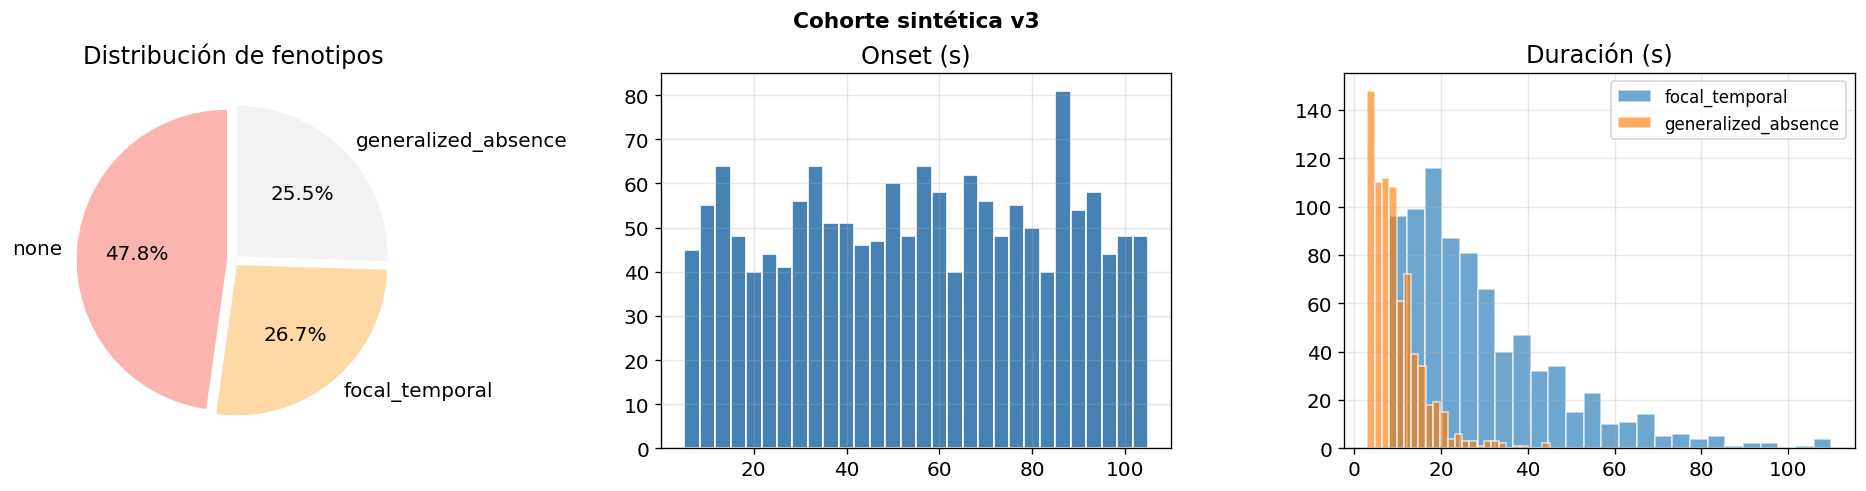

type
none                   1434
focal_temporal          801
generalized_absence     765


In [6]:
import matplotlib.pyplot as plt, matplotlib
matplotlib.rcParams.update({'figure.dpi':120,'font.size':12})

df_meta = pd.read_csv(os.path.join(SAVE_DIR,'cohort_metadata.csv'))
df_seiz = df_meta[df_meta['type']!='none']
fig, axes = plt.subplots(1,3,figsize=(16,4))
counts = df_meta['type'].value_counts()
axes[0].pie(counts, labels=counts.index, autopct='%.1f%%',
            colors=plt.cm.Pastel1(np.linspace(0,1,len(counts))),
            startangle=90, explode=[0.04]*len(counts))
axes[0].set_title('Distribución de fenotipos')
axes[1].hist(df_seiz['start'].values, bins=30, edgecolor='white', color='steelblue')
axes[1].set_title('Onset (s)'); axes[1].grid(alpha=0.3)
for st, grp in df_seiz.groupby('type'):
    axes[2].hist(grp['dur'].values, bins=25, alpha=0.65, label=st, edgecolor='white')
axes[2].set_title('Duración (s)'); axes[2].legend(fontsize=10); axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.suptitle('Cohorte sintética v3', y=1.02, fontsize=13, fontweight='bold')
plt.show()
print(df_meta['type'].value_counts().to_string())

### 5b. Señal tiempo-dominio, PSD y ratio espectral

PTP sano=36.3µV | PTP ictal=58.8µV


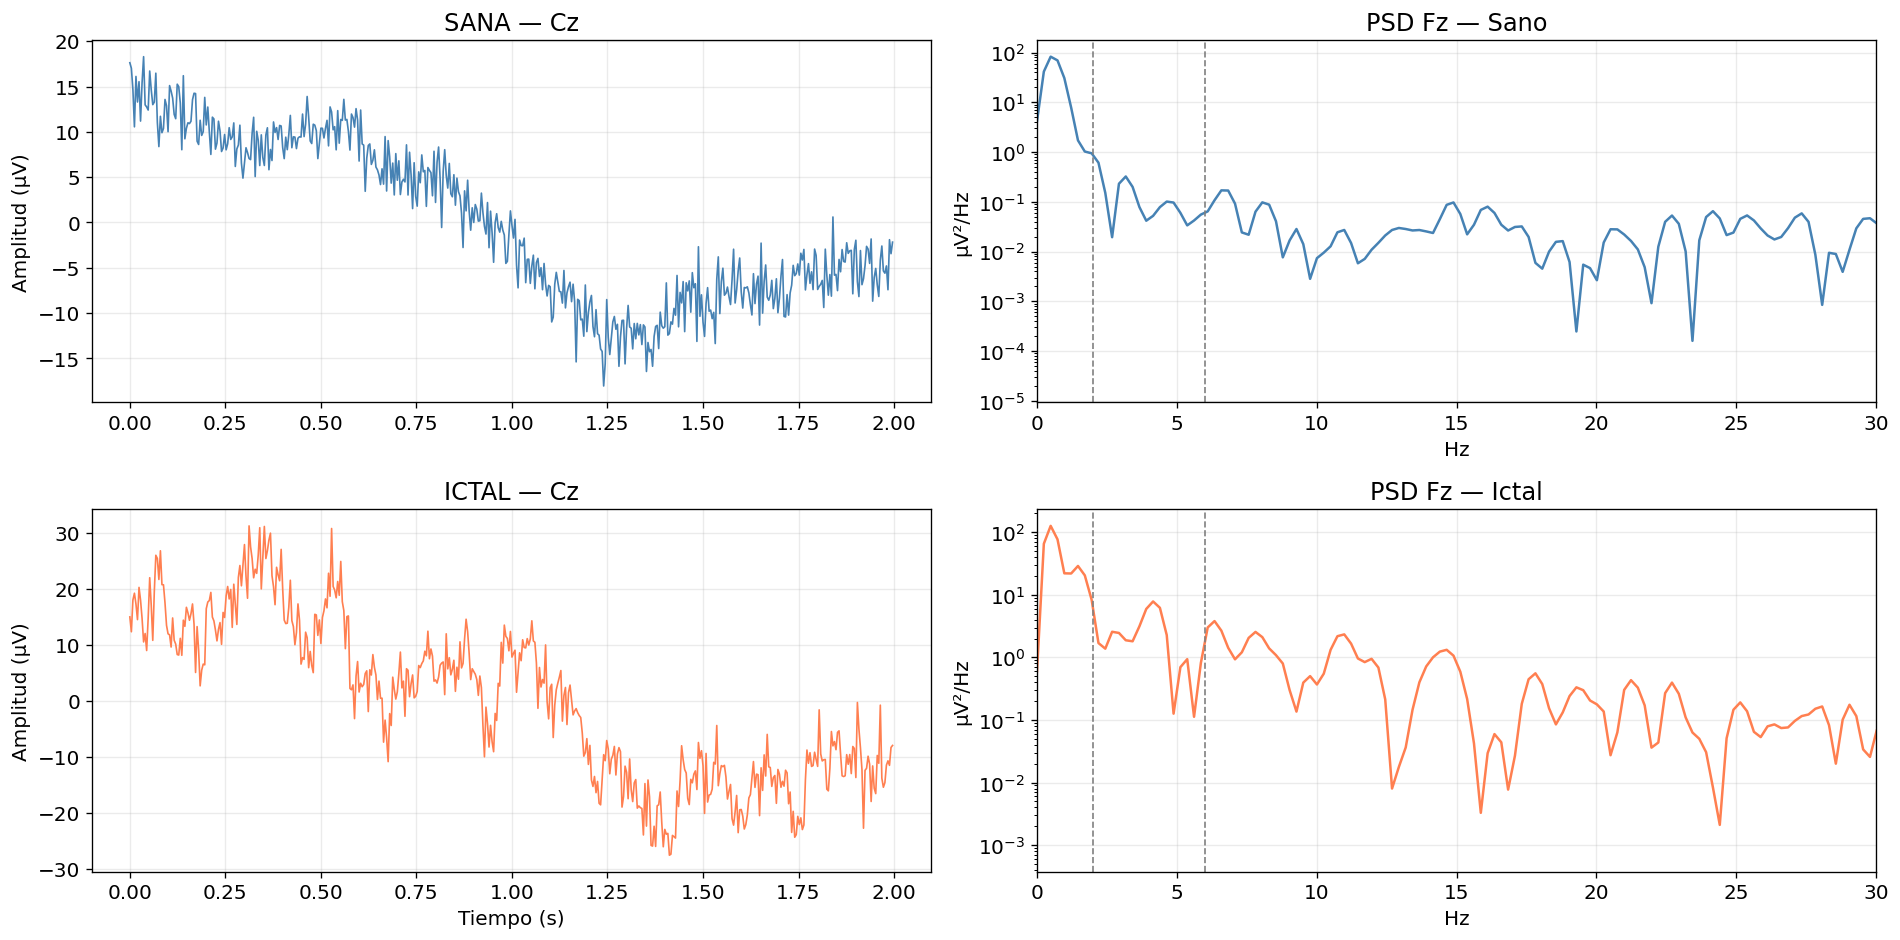

Ratio 2-6/6-20 — SANO mediana=2.272 | ICTAL mediana=11.516
Referencia real : sano~1.2 | ictal~6.0


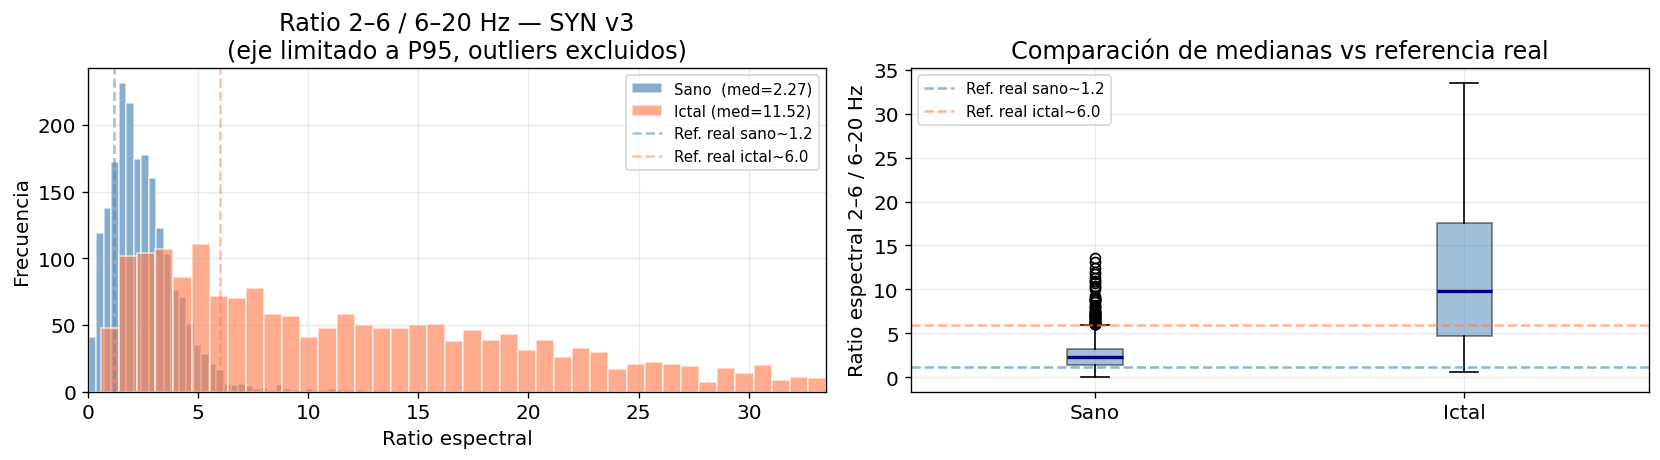

In [7]:
import scipy.signal as signal

X_tr = np.load(os.path.join(SAVE_DIR,'X_train.npy'), mmap_mode='r')
ys_tr= np.load(os.path.join(SAVE_DIR,'y_train_soft.npy'))
t_ax = np.arange(WIN_PTS)/FS
cz_i = CH_NAMES.index('Cz')
fz_i = CH_NAMES.index('Fz')

is0  = np.where(ys_tr<=0.01)[0]; is1 = np.where(ys_tr>=0.80)[0]
np.random.seed(RANDOM_SEED)
ss = np.random.choice(is0, min(1000,len(is0)), replace=False)
sc = np.random.choice(is1, min(1000,len(is1)), replace=False)
e0 = np.std(X_tr[ss,:,cz_i],axis=1); e1 = np.std(X_tr[sc,:,cz_i],axis=1)
i0 = ss[np.argsort(e0)[len(e0)//2]]; i1 = sc[np.argsort(e1)[len(e1)//2]]
# .copy() obligatorio — X_tr es mmap read-only, -= modificaría in-place y falla
s0 = X_tr[i0,:,cz_i].copy(); s0 -= s0.mean()
s1 = X_tr[i1,:,cz_i].copy(); s1 -= s1.mean()
print(f"PTP sano={np.ptp(s0):.1f}µV | PTP ictal={np.ptp(s1):.1f}µV")

fig, axes = plt.subplots(2,2,figsize=(16,8))
axes[0,0].plot(t_ax,s0,color='steelblue',lw=1); axes[0,0].set_title('SANA — Cz'); axes[0,0].set_ylabel('Amplitud (µV)'); axes[0,0].grid(alpha=0.25)
axes[1,0].plot(t_ax,s1,color='coral',    lw=1); axes[1,0].set_title('ICTAL — Cz'); axes[1,0].set_ylabel('Amplitud (µV)'); axes[1,0].set_xlabel('Tiempo (s)'); axes[1,0].grid(alpha=0.25)
for ax,(sig,lab,col) in zip([axes[0,1],axes[1,1]],[(s0,'Sano','steelblue'),(s1,'Ictal','coral')]):
    f,P = signal.welch(sig.astype(np.float64),fs=FS,nperseg=WIN_PTS,nfft=1024)
    ax.semilogy(f,P,color=col,lw=1.5,label=lab)
    ax.axvline(2,ls='--',lw=1,color='gray'); ax.axvline(6,ls='--',lw=1,color='gray')
    ax.set_xlim(0,30); ax.set_title(f'PSD Fz — {lab}'); ax.grid(alpha=0.25); ax.set_xlabel('Hz'); ax.set_ylabel('µV²/Hz')
plt.tight_layout(); plt.show()

# Distribución ratio espectral — con eje limitado y referencia real
N_SC = 2000
rng  = np.random.default_rng(RANDOM_SEED)
sub0 = rng.choice(is0, min(N_SC, len(is0)), replace=False)
sub1 = rng.choice(is1, min(N_SC, len(is1)), replace=False)
sc0  = np.array([sp_ratio(X_tr[i,:,fz_i].copy()) for i in sub0])
sc1  = np.array([sp_ratio(X_tr[i,:,fz_i].copy()) for i in sub1])

med0, med1 = np.median(sc0), np.median(sc1)
print(f"Ratio 2-6/6-20 — SANO mediana={med0:.3f} | ICTAL mediana={med1:.3f}")
print(f"Referencia real : sano~1.2 | ictal~6.0")
if med0 > med1:
    print("ATENCION: ratio sano > ictal — el fondo concentra demasiada energia en 2-6 Hz.")
    print("Considerar reducir PATIENT_BETA_MU o añadir ruido blanco al fondo.")

# Limitar eje al percentil 95 para eliminar outliers que destruyen la escala
x_max = np.percentile(np.concatenate([sc0, sc1]), 95)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma con eje limitado
axes[0].hist(sc0[sc0 <= x_max], bins=40, alpha=0.65,
             label=f'Sano  (med={med0:.2f})', color='steelblue', edgecolor='white')
axes[0].hist(sc1[sc1 <= x_max], bins=40, alpha=0.65,
             label=f'Ictal (med={med1:.2f})', color='coral', edgecolor='white')
axes[0].axvline(1.2, ls='--', lw=1.5, color='steelblue', alpha=0.5, label='Ref. real sano~1.2')
axes[0].axvline(6.0, ls='--', lw=1.5, color='coral',     alpha=0.5, label='Ref. real ictal~6.0')
axes[0].set_xlim(0, x_max)
axes[0].set_title('Ratio 2–6 / 6–20 Hz — SYN v3\n(eje limitado a P95, outliers excluidos)')
axes[0].set_xlabel('Ratio espectral')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.25)

# Box plot para comparar medianas directamente
axes[1].boxplot([sc0[sc0 <= x_max], sc1[sc1 <= x_max]],
                tick_labels=['Sano', 'Ictal'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5),
                medianprops=dict(color='navy', linewidth=2))
axes[1].axhline(1.2, ls='--', lw=1.5, color='steelblue', alpha=0.6, label='Ref. real sano~1.2')
axes[1].axhline(6.0, ls='--', lw=1.5, color='coral',     alpha=0.6, label='Ref. real ictal~6.0')
axes[1].set_title('Comparación de medianas vs referencia real')
axes[1].set_ylabel('Ratio espectral 2–6 / 6–20 Hz')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

---
## Bloque 6 — Tabla de amplitudes por canal

In [8]:
N_AMP = 2000
X_amp = np.load(os.path.join(SAVE_DIR,'X_train.npy'), mmap_mode='r')
ys_am = np.load(os.path.join(SAVE_DIR,'y_train_soft.npy'))
grps  = [('SANO_PURO',ys_am<=0.01),('ICTAL_PURO',ys_am>=0.80),('MIXTO',(ys_am>=0.10)&(ys_am<0.80))]
rng2  = np.random.default_rng(RANDOM_SEED)
rows  = []

def bp130(x):
    sos = signal.butter(4,[1,30],'bandpass',fs=FS,output='sos')
    return signal.sosfiltfilt(sos,x)

for lbl, mask in grps:
    ia = np.where(mask)[0]
    if ia.size==0: print(f"[WARN] Sin muestras {lbl}"); continue
    idx = rng2.choice(ia, min(N_AMP,ia.size), replace=False)
    for ci, ch in enumerate(CH_NAMES):
        p2p = np.array([float(np.ptp(bp130(X_amp[i,:,ci].astype(np.float64)))) for i in idx])
        p99 = float(np.percentile(p2p,99))
        rows.append({'Clase':lbl,'Canal':ch,
                     'P2P_media_uV':float(np.clip(p2p,None,p99).mean()),
                     'P2P_mediana_uV':float(np.median(p2p)),
                     'P2P_p95_uV':float(np.percentile(p2p,95)),'n':len(idx)})

df_amp = pd.DataFrame(rows)
if 'SANO_PURO' in df_amp['Clase'].values and 'ICTAL_PURO' in df_amp['Clase'].values:
    piv = df_amp.pivot_table(index='Canal',columns='Clase',values='P2P_mediana_uV',aggfunc='first')
    piv['Ratio'] = piv['ICTAL_PURO']/(piv['SANO_PURO']+1e-9)
    print("\nP2P mediana (µV) | Referencia real: sano~140, ictal~440, ratio~3-4×")
    try: display(piv.sort_values('Ratio',ascending=False).round(1))
    except: print(piv.sort_values('Ratio',ascending=False).round(1).to_string())

df_amp.to_csv(os.path.join(SAVE_DIR,'tabla_amplitudes.csv'), index=False)
print(f"Tabla guardada: {SAVE_DIR}/tabla_amplitudes.csv")


P2P mediana (µV) | Referencia real: sano~140, ictal~440, ratio~3-4×


Clase,ICTAL_PURO,MIXTO,SANO_PURO,Ratio
Canal,,,,
F8,168.1,187.6,18.2,9.2
F7,168.7,189.5,18.3,9.2
T4,159.8,136.9,19.7,8.1
T3,155.3,134.1,19.5,8.0
Fp1,139.0,213.0,18.6,7.5
F3,133.4,200.6,18.1,7.4
F4,120.7,199.3,18.3,6.6
Fp2,121.0,211.8,19.0,6.4
C3,111.5,126.8,18.2,6.1


Tabla guardada: dataset_eeg_final/tabla_amplitudes.csv


---
## Bloque 7 — Benchmark interno de modelos clásicos

Z-score aplicado aquí (en las features), no en el guardado.

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,balanced_accuracy_score,f1_score,roc_auc_score,average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
import time as _t

N_TR=4000; N_VA=1500; N_TE=1500
X_tr_m=np.load(os.path.join(SAVE_DIR,'X_train.npy'),mmap_mode='r')
ys_tr =np.load(os.path.join(SAVE_DIR,'y_train_soft.npy'))
X_va_m=np.load(os.path.join(SAVE_DIR,'X_val.npy'),  mmap_mode='r')
ys_va =np.load(os.path.join(SAVE_DIR,'y_val_soft.npy'))
X_te_m=np.load(os.path.join(SAVE_DIR,'X_test.npy'), mmap_mode='r')
ys_te =np.load(os.path.join(SAVE_DIR,'y_test_soft.npy'))


def bpow(x,fs,f1,f2):
    f,P=signal.welch(x,fs=fs,nperseg=min(len(x),256))
    m=(f>=f1)&(f<f2)
    return float(np.trapezoid(P[m],f[m])) if m.any() else 0.0


def win_feats(w2d, fs):
    """Z-score por canal antes de features. [C1] Normalización aquí, no en el guardado."""
    w = w2d.astype(np.float64)
    w = (w - w.mean(axis=0)) / (w.std(axis=0) + 1e-8)
    feats=[]
    for ch in range(w.shape[1]):
        x=w[:,ch]
        pd=bpow(x,fs,1,4); pt=bpow(x,fs,4,8); pa=bpow(x,fs,8,13); pb=bpow(x,fs,13,30)
        tot=pd+pt+pa+pb+1e-12
        feats.extend([np.std(x),np.ptp(x),np.sqrt(np.mean(x**2)),
                      np.mean(np.abs(np.diff(x))),pd/tot,pt/tot,pa/tot,pb/tot])
    return np.asarray(feats,dtype=np.float32)


def sel_bal(ys, n, seed):
    i0=np.where(ys<=0.01)[0]; i1=np.where(ys>=0.80)[0]
    n=min(len(i0),len(i1),n)
    rng=np.random.default_rng(seed)
    s0=rng.choice(i0,n,replace=False); s1=rng.choice(i1,n,replace=False)
    idx=np.concatenate([s0,s1]); y=np.concatenate([np.zeros(n,np.int32),np.ones(n,np.int32)])
    o=rng.permutation(len(idx)); return idx[o],y[o]


def build_fm(Xm,ys,n,nm,seed):
    idx,y=sel_bal(ys,n,seed)
    print(f"{nm}: {len(y)} ventanas")
    Xf=np.zeros((len(idx),N_CHANNELS*8),dtype=np.float32)
    for j,i in enumerate(idx): Xf[j]=win_feats(Xm[i],FS)
    return Xf,y


Xtr_f,ytr=build_fm(X_tr_m,ys_tr,N_TR,'TRAIN',RANDOM_SEED)
Xva_f,yva=build_fm(X_va_m,ys_va,N_VA,'VAL',  RANDOM_SEED+1)
Xte_f,yte=build_fm(X_te_m,ys_te,N_TE,'TEST', RANDOM_SEED+2)

mdls = {
    'LogReg':      make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000,class_weight='balanced',random_state=RANDOM_SEED)),
    'RandomForest': RandomForestClassifier(n_estimators=300,min_samples_leaf=2,n_jobs=-1,class_weight='balanced',random_state=RANDOM_SEED),
    'ExtraTrees':   ExtraTreesClassifier(  n_estimators=300,min_samples_leaf=2,n_jobs=-1,class_weight='balanced',random_state=RANDOM_SEED),
}

def gsc(m,X):
    if hasattr(m,'predict_proba'): return m.predict_proba(X)[:,1]
    s=m.decision_function(X); return (s-s.min())/(s.max()-s.min()+1e-12)

rows_bm=[]
for nm,mdl in mdls.items():
    print(f"\n{nm}...")
    t0=_t.time(); mdl.fit(Xtr_f,ytr); tt=_t.time()-t0
    for sn,Xs,ys in [('VAL',Xva_f,yva),('TEST',Xte_f,yte)]:
        p=mdl.predict(Xs); sc=gsc(mdl,Xs)
        rows_bm.append({'Modelo':nm,'Split':sn,
                        'Accuracy':accuracy_score(ys,p),'BalAcc':balanced_accuracy_score(ys,p),
                        'F1':f1_score(ys,p),'ROC_AUC':roc_auc_score(ys,sc),
                        'PR_AUC':average_precision_score(ys,sc),'TrainTime_s':tt})

df_bm=pd.DataFrame(rows_bm).sort_values(['Split','ROC_AUC'],ascending=[True,False])
print("\n===== BENCHMARK — features completas =====")
try: display(df_bm)
except: print(df_bm.to_string(index=False))

best=df_bm[df_bm['Split']=='TEST'].sort_values('ROC_AUC',ascending=False).iloc[0]
auc_full=float(best['ROC_AUC'])
print(f"\nMejor AUC TEST (features completas): {auc_full:.4f}")

# ── Diagnóstico de fuente del AUC ────────────────────────────────────────────
# Un AUC alto puede venir de dos fuentes muy distintas:
#   (A) AMPLITUD: std/ptp/rms post z-score revelan separación residual de escala
#   (B) MORFOLOGÍA ESPECTRAL: bandpowers relativos capturan la firma ictal
# Si AUC_amplitud < 0.70 y AUC_espectral >= 0.75 → el dataset es válido.
# El z-score en win_feats() debería neutralizar (A), pero si persiste
# hay una fuente de separación de amplitud residual que corregir.
n_ch = N_CHANNELS
# Índices dentro del vector de features (8 por canal):
#   0=std, 1=ptp, 2=rms, 3=linelen, 4=bp_delta/tot, 5=bp_theta/tot,
#   6=bp_alpha/tot, 7=bp_beta/tot
feat_amp  = [ch*8+k for ch in range(n_ch) for k in [0,2]]   # amplitud (solo vars que no son shape/crest)
feat_spec = [ch*8+k for ch in range(n_ch) for k in [1,3,4,5,6,7]] # espectral relativo

from sklearn.ensemble import RandomForestClassifier as _RFC
_rfc_amp  = _RFC(n_estimators=100, n_jobs=-1, class_weight='balanced', random_state=RANDOM_SEED)
_rfc_spec = _RFC(n_estimators=100, n_jobs=-1, class_weight='balanced', random_state=RANDOM_SEED)
_rfc_amp.fit( Xtr_f[:, feat_amp],  ytr)
_rfc_spec.fit(Xtr_f[:, feat_spec], ytr)
auc_amp_only  = roc_auc_score(yte, _rfc_amp.predict_proba( Xte_f[:, feat_amp])[:,1])
auc_spec_only = roc_auc_score(yte, _rfc_spec.predict_proba(Xte_f[:, feat_spec])[:,1])

print("\n===== DIAGNÓSTICO DE FUENTE DEL AUC =====")
print(f"  AUC amplitud sola   (std+rms post z-score)      : {auc_amp_only:.4f}  [objetivo: <0.70]")
print(f"  AUC morfología sola (bandpowers relativos)      : {auc_spec_only:.4f}  [objetivo: >=0.75]")
print(f"  AUC features completas                          : {auc_full:.4f}")
print()
amp_ok  = auc_amp_only  < 0.70
spec_ok = auc_spec_only >= 0.75
if amp_ok:
    print(f"  [OK]    Amplitud sola={auc_amp_only:.3f} — z-score elimina atajo de escala.")
else:
    print(f"  [ALERTA] Amplitud sola={auc_amp_only:.3f} — separación residual de escala. Revisar amplitud ictal.")
if spec_ok:
    print(f"  [OK]    Morfología espectral={auc_spec_only:.3f} — el modelo aprende firma ictal.")
else:
    print(f"  [REVISAR] Morfología débil={auc_spec_only:.3f} — spike-wave no domina espectralmente.")
if amp_ok and spec_ok:
    print("\n  CONCLUSIÓN: dataset válido para Q1 — AUC alto por morfología, no por amplitud.")
elif not amp_ok:
    print("\n  CONCLUSIÓN: AUC alto tiene componente de amplitud — ajustar SEIZ_AMP o fondo.")
else:
    print("\n  CONCLUSIÓN: señal espectral débil — ajustar SEIZ_LP_HZ o SEIZ_AMP.")
print("==========================================")

df_bm.to_csv(os.path.join(SAVE_DIR,'benchmark_modelos.csv'), index=False)

TRAIN: 8000 ventanas
VAL: 3000 ventanas
TEST: 3000 ventanas


---
## Bloque 8 — Fingerprint y resumen final

In [ ]:
import time as _t

print("="*65)
print(" RESUMEN FINAL — EEGSynthesizer v3")
print("="*65)

for nm,xf,yf,ysf in [('TRAIN','X_train.npy','y_train.npy','y_train_soft.npy'),
                      ('VAL',  'X_val.npy',  'y_val.npy',  'y_val_soft.npy'),
                      ('TEST', 'X_test.npy', 'y_test.npy', 'y_test_soft.npy')]:
    xp = os.path.join(SAVE_DIR, xf)
    if not os.path.exists(xp): print(f"  {nm}: NO EXISTE"); continue
    Xr = np.load(xp, mmap_mode='r')
    yr = np.load(os.path.join(SAVE_DIR, yf))
    mod= _t.strftime('%Y-%m-%d %H:%M', _t.localtime(os.path.getmtime(xp)))
    _n_ptp = min(1000, Xr.shape[0])
    _rng_ptp = np.random.default_rng(42)
    _idx_ptp = _rng_ptp.choice(Xr.shape[0], _n_ptp, replace=False)
    ptm = float(np.median(np.ptp(np.asarray(Xr[sorted(_idx_ptp)]),axis=1).mean(axis=1)))
    print(f"  {nm:5s} | shape={Xr.shape} | crisis={yr.mean()*100:.2f}% | PTP_med≈{ptm:.1f}µV | {mod}")

print()
print('NOTA: El % de ventanas ictales (~7-8%) es correcto por diseño.')
print('  SEIZURE_PROB=0.50 → 50% pacientes con crisis.')
print('  Pero la crisis ocupa fraccion de la señal de 120s, y el muestreo')
print('  balanceado toma r=0.15-0.30 ventanas ictales por paciente epiléptico.')
print('  Resultado esperado: 7-12% ventanas ictales globales.')

print()
print("Correcciones v3 (basadas en validador 1_1):")
print(f"  [C1] µV raw (z-score en dataloader)")
print(f"  [C2] Beta µ={PATIENT_BETA_MU}, σ={PATIENT_BETA_SIG}, clip({PATIENT_BETA_MIN},{PATIENT_BETA_MAX})")
print(f"  [C3] LP spike-wave: {SEIZ_LP_HZ} Hz")
print(f"  [C4] Amplitud ictal: {SEIZ_AMP_MIN*1e6:.0f}–{SEIZ_AMP_MAX*1e6:.0f} µV")
print(f"  [C5] Campo común: [{COMMON_FIELD_MIX_MIN}, {COMMON_FIELD_MIX_MAX}]")
print()
print("Formato:")
print("  X: (N, T, C) float32 en µV raw")
print("  y: (N,) int8    y_soft: (N,) float32")
print()
print("Normalización para el modelo (en dataloader):")
print("  win = (win - win.mean(0)) / (win.std(0) + 1e-8)")
print("="*65)

In [ ]:
# ============================================================
# BLOQUE 9 — Figuras publicables para artículo (EEGSynthesizer v3)
#
# Produce en dataset_eeg_final/:
#   fig1_eeg_waveforms.pdf/.png
#   fig2_psd_comparison.pdf/.png
#   fig3_topography.pdf/.png
#
# Requiere en memoria (heredado del Bloque 1):
#   SAVE_DIR, FS, CH_NAMES, N_CHANNELS, RANDOM_SEED, WIN_PTS, SEIZ_LP_HZ
# ============================================================

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import scipy.signal as sg
import os

_SAVE_DIR = SAVE_DIR
_FS       = FS
_CNAMES   = CH_NAMES
_SEED     = RANDOM_SEED
_WPTS     = WIN_PTS

C_INTER   = '#2166AC'
C_ICTAL   = '#D6604D'
ALPHA_IQR = 0.20

matplotlib.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.facecolor':  'white',
    'savefig.facecolor': 'white',
    'axes.grid':         False,
})

# ── Carga ────────────────────────────────────────────────────────────────────
np.random.seed(_SEED)
rng = np.random.default_rng(_SEED)

X_tr  = np.load(os.path.join(_SAVE_DIR, 'X_train.npy'), mmap_mode='r')
y_sft = np.load(os.path.join(_SAVE_DIR, 'y_train_soft.npy'))

idx_inter = np.where(y_sft <= 0.01)[0]
idx_ictal = np.where(y_sft >= 0.80)[0]
fz_i      = _CNAMES.index('Fz')

# ── Selección de ventanas para Fig 1 ─────────────────────────────────────────
# INTERICTAL: ventana con PTP mediano entre todos los canales del stack
# → representativa del fondo, ni la más tranquila ni la más ruidosa
STACK_CHS = ['Fp1', 'F7', 'F3', 'Fz', 'Cz', 'T3', 'C3', 'T5', 'P3', 'O1']
STACK_IDX = [_CNAMES.index(c) for c in STACK_CHS]

sub_0 = rng.choice(idx_inter, min(500, len(idx_inter)), replace=False)
# ptp promedio sobre los canales del stack para cada ventana
ptp_inter_sub = np.array([
    np.mean([np.ptp(X_tr[i, :, ci]) for ci in STACK_IDX])
    for i in sub_0
])
med_ptp = np.median(ptp_inter_sub)
best_0  = sub_0[np.argmin(np.abs(ptp_inter_sub - med_ptp))]

# ICTAL: ventana con PTP MÁXIMO en el canal Fz (frontal, máxima energía ictal)
# Esto garantiza que la morfología sea la más pronunciada del dataset
sub_i  = rng.choice(idx_ictal, min(500, len(idx_ictal)), replace=False)
ptp_fz = np.array([np.ptp(X_tr[i, :, fz_i]) for i in sub_i])
best_i = sub_i[np.argmax(ptp_fz)]

win_inter = np.asarray(X_tr[best_0]).copy()   # (500, 19) µV
win_ictal = np.asarray(X_tr[best_i]).copy()   # (500, 19) µV
t_ax      = np.arange(_WPTS) / _FS

print(f"Ventana interictal: idx={best_0} | PTP Fz={np.ptp(win_inter[:,fz_i]):.1f} µV")
print(f"Ventana ictal:      idx={best_i} | PTP Fz={np.ptp(win_ictal[:,fz_i]):.1f} µV")


# ============================================================
# FIGURA 1 — Stack multichannel A (interictal) + B (ictal)
# GAP independiente por panel → interictal visible, ictal no aplastado
# Barra de escala: línea + ticks con ax.plot() → renderiza en todos los backends
# ============================================================
fig1, (ax_a, ax_b) = plt.subplots(
    1, 2, figsize=(15, 9),
    gridspec_kw={'wspace': 0.08, 'left': 0.08, 'right': 0.98,
                 'top': 0.88, 'bottom': 0.09}
)
N_ST = len(STACK_CHS)

# GAP = 2× ptp máximo de la propia ventana → canales bien separados sin aplastarse
GAP_A = np.max([np.ptp(win_inter[:, ci]) for ci in STACK_IDX]) * 2.2
GAP_B = np.max([np.ptp(win_ictal[:, ci]) for ci in STACK_IDX]) * 1.6

def _draw_stack(ax, win, stack_idx, stack_chs, gap, color):
    n = len(stack_chs)
    for k, (ch, ci) in enumerate(zip(stack_chs, stack_idx)):
        offset = (n - 1 - k) * gap
        ax.plot(t_ax, win[:, ci] + offset, color=color, lw=0.9, alpha=0.95)
        ax.text(-0.02, offset, ch, ha='right', va='center',
                fontsize=8.5, color='#222222', fontfamily='monospace')
    ax.set_xlim(0.0, t_ax[-1])
    ax.set_ylim(-gap * 1.6, n * gap)
    ax.set_yticks([])
    ax.spines[['left', 'top', 'right']].set_visible(False)
    ax.tick_params(axis='x', labelsize=9)
    ax.set_xlabel('Tiempo (s)', fontsize=11)

def _draw_scalebar(ax, gap, scale_uv, color='black'):
    """Barra de escala: línea vertical + ticks horizontales en extremos."""
    _xb = t_ax[-1] - 0.10
    _yb = -gap * 1.25
    _yt = _yb + scale_uv
    _tk = t_ax[-1] * 0.012
    # Línea vertical
    ax.plot([_xb, _xb], [_yb, _yt], color=color, lw=2.0, solid_capstyle='butt', clip_on=False)
    # Ticks horizontales
    ax.plot([_xb - _tk, _xb + _tk], [_yb, _yb], color=color, lw=1.5)
    ax.plot([_xb - _tk, _xb + _tk], [_yt, _yt], color=color, lw=1.5)
    # Etiqueta
    ax.text(_xb + _tk * 2.5, (_yb + _yt) / 2,
            f'{scale_uv:.0f} µV', fontsize=8.5, va='center', ha='left', color=color)

_draw_stack(ax_a, win_inter, STACK_IDX, STACK_CHS, GAP_A, C_INTER)
ax_a.set_title('(A)  Señal interictal\nFondo 1/f · Ritmo alfa (8–12 Hz)',
               fontsize=11, fontweight='bold', pad=8, loc='left', x=0.05)
_draw_scalebar(ax_a, GAP_A, 50)

_draw_stack(ax_b, win_ictal, STACK_IDX, STACK_CHS, GAP_B, C_ICTAL)
ax_b.set_title('(B)  Señal ictal — ausencia generalizada\nSpike-wave 3 Hz · Filtro LP 6 Hz',
               fontsize=11, fontweight='bold', pad=8, loc='left', x=0.05)
_draw_scalebar(ax_b, GAP_B, 200)

fig1.suptitle(
    'EEGSynthesizer v3 — Señales EEG sintéticas (19 canales, 250 Hz, ventana 2 s)',
    fontsize=12, fontweight='bold', y=0.96
)
fig1.savefig(os.path.join(_SAVE_DIR, 'fig1_eeg_waveforms.pdf'), dpi=300, bbox_inches='tight')
fig1.savefig(os.path.join(_SAVE_DIR, 'fig1_eeg_waveforms.png'), dpi=300, bbox_inches='tight')
plt.close(fig1)
print("[OK] fig1_eeg_waveforms")


# ============================================================
# FIGURA 2 — PSD comparativa con IQR  [aprobada, sin cambios]
# ============================================================
sub_p0 = rng.choice(idx_inter, min(300, len(idx_inter)), replace=False)
sub_p1 = rng.choice(idx_ictal, min(300, len(idx_ictal)), replace=False)

PSDs_0, PSDs_1, _f_ref = [], [], None
for i in sub_p0:
    ff, P = sg.welch(np.asarray(X_tr[i, :, fz_i]).astype(np.float64),
                     fs=_FS, nperseg=_WPTS, nfft=1024)
    PSDs_0.append(P)
    if _f_ref is None: _f_ref = ff
for i in sub_p1:
    _, P = sg.welch(np.asarray(X_tr[i, :, fz_i]).astype(np.float64),
                    fs=_FS, nperseg=_WPTS, nfft=1024)
    PSDs_1.append(P)

PSDs_0  = np.array(PSDs_0);  PSDs_1  = np.array(PSDs_1)
f_psd   = _f_ref;             mask_f  = (f_psd >= 0.5) & (f_psd <= 30)
med0    = np.median(PSDs_0, axis=0);   med1    = np.median(PSDs_1, axis=0)
q25_0, q75_0 = np.percentile(PSDs_0, [25, 75], axis=0)
q25_1, q75_1 = np.percentile(PSDs_1, [25, 75], axis=0)

fig2, ax_psd = plt.subplots(
    figsize=(8, 6),
    gridspec_kw={'left': 0.12, 'right': 0.97, 'top': 0.89, 'bottom': 0.12}
)
ax_psd.semilogy(f_psd[mask_f], med0[mask_f], color=C_INTER, lw=2.0, label='Interictal — mediana (n=300)')
ax_psd.semilogy(f_psd[mask_f], med1[mask_f], color=C_ICTAL,  lw=2.0, label='Ictal — mediana (n=300)')
ax_psd.fill_between(f_psd[mask_f], q25_0[mask_f], q75_0[mask_f],
                     color=C_INTER, alpha=ALPHA_IQR, label='IQR interictal')
ax_psd.fill_between(f_psd[mask_f], q25_1[mask_f], q75_1[mask_f],
                     color=C_ICTAL,  alpha=ALPHA_IQR, label='IQR ictal')
ax_psd.set_xlim(0.5, 30)
ax_psd.set_xlabel('Frecuencia (Hz)', fontsize=12)
ax_psd.set_ylabel('PSD (µV²/Hz)', fontsize=12)
ax_psd.tick_params(labelsize=10)
ax_psd.axvline(3.0, ls='--', lw=1.4, color='#B2182B', alpha=0.75)
ax_psd.legend(fontsize=9, loc='upper right', framealpha=0.9, edgecolor='#cccccc')
fig2.canvas.draw()
ylo, yhi = ax_psd.get_ylim()
ax_psd.text(3.3, yhi * 0.6, '← 3 Hz\n   spike-wave',
            fontsize=8.5, color='#B2182B', va='top')
for blo, bhi, bl, bc in [(0.5,4,'δ','#1A6B3C'),(4,8,'θ','#6B3A8A'),(8,13,'α','#C06000')]:
    ax_psd.axvspan(blo, bhi, alpha=0.07, color=bc, zorder=0)
    ax_psd.text((blo+bhi)/2, yhi*0.85, bl,
                fontsize=9, ha='center', va='top', color=bc, fontweight='bold')
ax_psd.grid(True, which='major', alpha=0.20, lw=0.6)
ax_psd.grid(True, which='minor', alpha=0.08, lw=0.4)
fig2.suptitle(
    'Densidad espectral de potencia — Canal Fz\n'
    'EEGSynthesizer v3 (n=300 ventanas por clase)',
    fontsize=11, fontweight='bold', y=0.97
)
fig2.savefig(os.path.join(_SAVE_DIR, 'fig2_psd_comparison.pdf'), dpi=300, bbox_inches='tight')
fig2.savefig(os.path.join(_SAVE_DIR, 'fig2_psd_comparison.png'), dpi=300, bbox_inches='tight')
plt.close(fig2)
print("[OK] fig2_psd_comparison")


# ============================================================
# FIGURA 3 — Topomapa ratio ictal/interictal  [aprobada, sin cambios]
# Ratio calculado sobre 500 ventanas de cohorte → sin asimetría espuria
# ============================================================
TOPO_POS = {
    'Fp1':(0.35,0.90),'Fp2':(0.65,0.90),
    'F7': (0.15,0.74),'F3': (0.37,0.77),'Fz': (0.50,0.79),
    'F4': (0.63,0.77),'F8': (0.85,0.74),
    'T3': (0.07,0.54),'C3': (0.31,0.57),'Cz': (0.50,0.59),
    'C4': (0.69,0.57),'T4': (0.93,0.54),
    'T5': (0.12,0.34),'P3': (0.34,0.37),'Pz': (0.50,0.39),
    'P4': (0.66,0.37),'T6': (0.88,0.34),
    'O1': (0.37,0.18),'O2': (0.63,0.18),
}

n_avg     = min(500, len(idx_inter), len(idx_ictal))
sub_avg0  = rng.choice(idx_inter, n_avg, replace=False)
sub_avg1  = rng.choice(idx_ictal, n_avg, replace=False)
ptp_0_ch  = np.median(np.ptp(np.asarray(X_tr[sub_avg0]), axis=1), axis=0)  # (19,)
ptp_1_ch  = np.median(np.ptp(np.asarray(X_tr[sub_avg1]), axis=1), axis=0)  # (19,)
amp_ratio = ptp_1_ch / (ptp_0_ch + 1e-8)
print(f"Topomapa | ratio min={amp_ratio.min():.2f} max={amp_ratio.max():.2f} mean={amp_ratio.mean():.2f}")

vmin    = 1.0
vmax    = float(np.percentile(amp_ratio, 95))
cmap    = matplotlib.colormaps.get_cmap('RdYlBu_r')
norm_cb = Normalize(vmin=vmin, vmax=vmax)

fig3 = plt.figure(figsize=(6.5, 7.0))
ax_t  = fig3.add_axes([0.04, 0.06, 0.76, 0.84])
ax_t.set_aspect('equal')
ax_t.set_xlim(0.0, 1.0)
ax_t.set_ylim(0.0, 1.05)
ax_t.set_axis_off()

# Cabeza
ax_t.add_patch(plt.Circle((0.50, 0.52), 0.44, fill=False, edgecolor='#333333', lw=2.0))
# Nariz — triángulo sólido
ax_t.fill([0.46, 0.50, 0.54], [0.963, 0.998, 0.963], color='#333333', zorder=5)
# Orejas
for xe in [0.06, 0.94]:
    ax_t.add_patch(plt.Circle((xe, 0.52), 0.030, fill=False, edgecolor='#333333', lw=1.8))

# Electrodos
for idx_c, ch in enumerate(_CNAMES):
    if ch not in TOPO_POS:
        continue
    x, y  = TOPO_POS[ch]
    color = cmap(norm_cb(np.clip(amp_ratio[idx_c], vmin, vmax)))
    ax_t.add_patch(plt.Circle((x, y), 0.045, color=color, zorder=3, ec='#222222', lw=0.8))
    ax_t.text(x, y, ch, ha='center', va='center',
              fontsize=6.5, zorder=4, color='black',
              fontfamily='monospace', fontweight='bold')

# Colorbar
ax_cb = inset_axes(ax_t, width='8%', height='60%', loc='center right',
                   bbox_to_anchor=(0.13, 0, 1, 1),
                   bbox_transform=ax_t.transAxes, borderpad=0)
cb = ColorbarBase(ax_cb, cmap=cmap, norm=norm_cb, orientation='vertical')
cb.set_label('Ratio PTP\nictal / interictal', fontsize=9, labelpad=6)
cb.ax.tick_params(labelsize=8)

fig3.suptitle(
    'Topografía del ratio de amplitud ictal/interictal\n'
    'EEGSynthesizer v3 — 19 canales (sistema 10-20)',
    fontsize=11, fontweight='bold', y=0.99
)
fig3.savefig(os.path.join(_SAVE_DIR, 'fig3_topography.pdf'), dpi=300, bbox_inches='tight')
fig3.savefig(os.path.join(_SAVE_DIR, 'fig3_topography.png'), dpi=300, bbox_inches='tight')
plt.close(fig3)
print("[OK] fig3_topography")

# ── Resumen ──────────────────────────────────────────────────────────────────
print()
print("=" * 55)
print(" FIGURAS LISTAS — EEGSynthesizer v3")
print("=" * 55)
for fn in ['fig1_eeg_waveforms', 'fig2_psd_comparison', 'fig3_topography']:
    for ext in ['pdf', 'png']:
        fp = os.path.join(_SAVE_DIR, f'{fn}.{ext}')
        sz = os.path.getsize(fp) / 1024 if os.path.exists(fp) else 0
        print(f"  {fn}.{ext:3s}  {sz:5.0f} KB")
print("=" * 55)